# Chapter 13: Varying slopes, non-nested models, and other complexities

Reproducing examples from Gelman & Hill (2007), Chapter 13,
using **interlace**. All results verified against R `lme4::lmer()`.

This chapter extends Chapter 12 in three directions:

1. **Varying slopes** — the effect of a predictor can differ by group
2. **Group-level predictors for slopes** — explaining why slopes vary
3. **Non-nested / crossed random effects** — groups that are not hierarchical

| Model | Formula | Dataset | Section |
|-------|---------|---------|--------|
| M3 | `y ~ x + (1 + x \| county)` | radon | 13.1 |
| M4 | `y ~ x + u + x:u + (1 + x \| county)` | radon | 13.1 |
| Earnings M1 | `y ~ x + (1 + x \| eth)` | heights | 13.4 |
| Earnings M2 | `y ~ x_centered + (1 + x_centered \| eth)` | heights | 13.4 |
| Pilots | `y ~ 1 + (1 \| group) + (1 \| scenario)` | pilots | 13.5 |

In [1]:
import json
import numpy as np
import pandas as pd
import interlace
from pathlib import Path
from plotnine import (
    ggplot, aes,
    geom_point, geom_line, geom_abline, geom_hline,
    geom_errorbar, geom_segment, geom_text, geom_tile,
    facet_wrap, facet_grid, labs, theme_bw, theme,
    scale_x_continuous, scale_y_continuous, scale_fill_gradient,
    coord_cartesian,
)

FIXTURE_DIR = Path("../../tests/fixtures")

## 1. Load data

In [2]:
# Radon data (same as Ch 12)
df = pd.read_csv(FIXTURE_DIR / "gh_ch12_radon_data.csv")
county_df = pd.read_csv(FIXTURE_DIR / "gh_ch12_county_data.csv")
print(f"Radon: {len(df)} obs, {df['county'].nunique()} counties")

# Pilots data
pilots_df = pd.read_csv(FIXTURE_DIR / "gh_ch13_pilots_data.csv")
print(f"Pilots: {len(pilots_df)} obs, {pilots_df['group_id'].nunique()} groups, "
      f"{pilots_df['scenario_id'].nunique()} scenarios")

# Earnings data
earn_df = pd.read_csv(FIXTURE_DIR / "gh_ch13_earnings_data.csv")
eth_labels = {1: "Black", 2: "Hispanic", 3: "White", 4: "Other"}
earn_df["eth_label"] = earn_df["eth"].map(eth_labels)
print(f"Earnings: {len(earn_df)} obs, {earn_df['eth'].nunique()} ethnicities")

Radon: 919 obs, 85 counties
Pilots: 40 obs, 5 groups, 8 scenarios
Earnings: 1062 obs, 4 ethnicities


## 2. Model M3: Varying intercepts and slopes (Section 13.1)

$$y_i \sim N(\alpha_{j[i]} + \beta_{j[i]} x_i,\; \sigma_y^2)$$
$$\begin{pmatrix} \alpha_j \\ \beta_j \end{pmatrix} \sim N\left(
\begin{pmatrix} \mu_\alpha \\ \mu_\beta \end{pmatrix},
\begin{pmatrix} \sigma_\alpha^2 & \rho\sigma_\alpha\sigma_\beta \\
\rho\sigma_\alpha\sigma_\beta & \sigma_\beta^2 \end{pmatrix}\right)$$

Both the intercept (baseline radon) and the floor effect can vary by county.
The `(1 + x | county)` syntax estimates the full 2x2 covariance.

In [3]:
M3 = interlace.fit("y ~ x", data=df, random=["(1 + x | county)"])
print(M3.summary())

Linear mixed model fit by REML

Formula: y ~ x

REML criterion at convergence: -1084.2

Scaled residuals:
  Min:  -4.4044  1Q:  -0.6224  Median:   0.0138  3Q:   0.6123  Max:   3.5682

Random effects:
 Groups          Name                Variance   Std.Dev.
 county          (Intercept)         0.121584   0.348689
 county          x                   0.118070   0.343613
                                                 -0.3374  [corr (Intercept),x]
 Residual                            0.556745   0.746154

Number of obs: 919, groups: county, 85

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  1.4628       0.0539     77.7    27.1549   0.0000e+00 ***
  x                         -0.6811       0.0876     41.2    -7.7765   1.3039e-09 ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 2180.32  BIC: 2209.26  logLik: -1084.16


In [4]:
# Validate M3 against R lme4
with open(FIXTURE_DIR / "gh_ch13_M3_results.json") as f:
    r_M3 = json.load(f)

print("=== M3 validation against R lme4 ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)

# Fixed effects
fe_map = {"(Intercept)": "Intercept", "x": "x"}
for r_name, py_name in fe_map.items():
    py_val = M3.fe_params[py_name]
    r_val = r_M3["fixed_effects"][r_name]
    print(f"{r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

# Variance components
vc = r_M3["variance_components"]
py_vc = M3.variance_components

# county intercept variance
py_int_var = py_vc["county"]
# For a model with (1+x|county), interlace stores the full VC
# Let's get from VarCorr
vc_info = interlace.VarCorr(M3)
print(f"\nVarCorr:")
print(vc_info)

print(f"\nR correlation (intercept, slope): {r_M3.get('cor_county', 'N/A')}")

# Log-likelihood
print(f"\n{'loglik':<25} {M3.llf:>12.4f} {r_M3['loglik']:>12.4f} {abs(M3.llf - r_M3['loglik']):>12.2e}")

# Theta
print(f"theta (interlace): {M3.theta}")
print(f"theta (R):         {r_M3['theta']}")

=== M3 validation against R lme4 ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   1.462770     1.462770     3.63e-07
x                            -0.681098    -0.681098     8.41e-08

VarCorr:

R correlation (intercept, slope): -0.33737494782

loglik                      -1084.1623   -1084.1623     6.40e-09
theta (interlace): [ 0.46731519 -0.15537909  0.43350767]
theta (R):         [0.46730938949, -0.15536005862, 0.43349796547]


## 3. Figure 13.1: Varying slopes across eight counties

Each county now has its own intercept *and* slope. Compare to Figure 12.4
where only intercepts varied.

RE type: <class 'pandas.DataFrame'>, shape: (85, 2)
RE columns: ['(Intercept)', 'x']


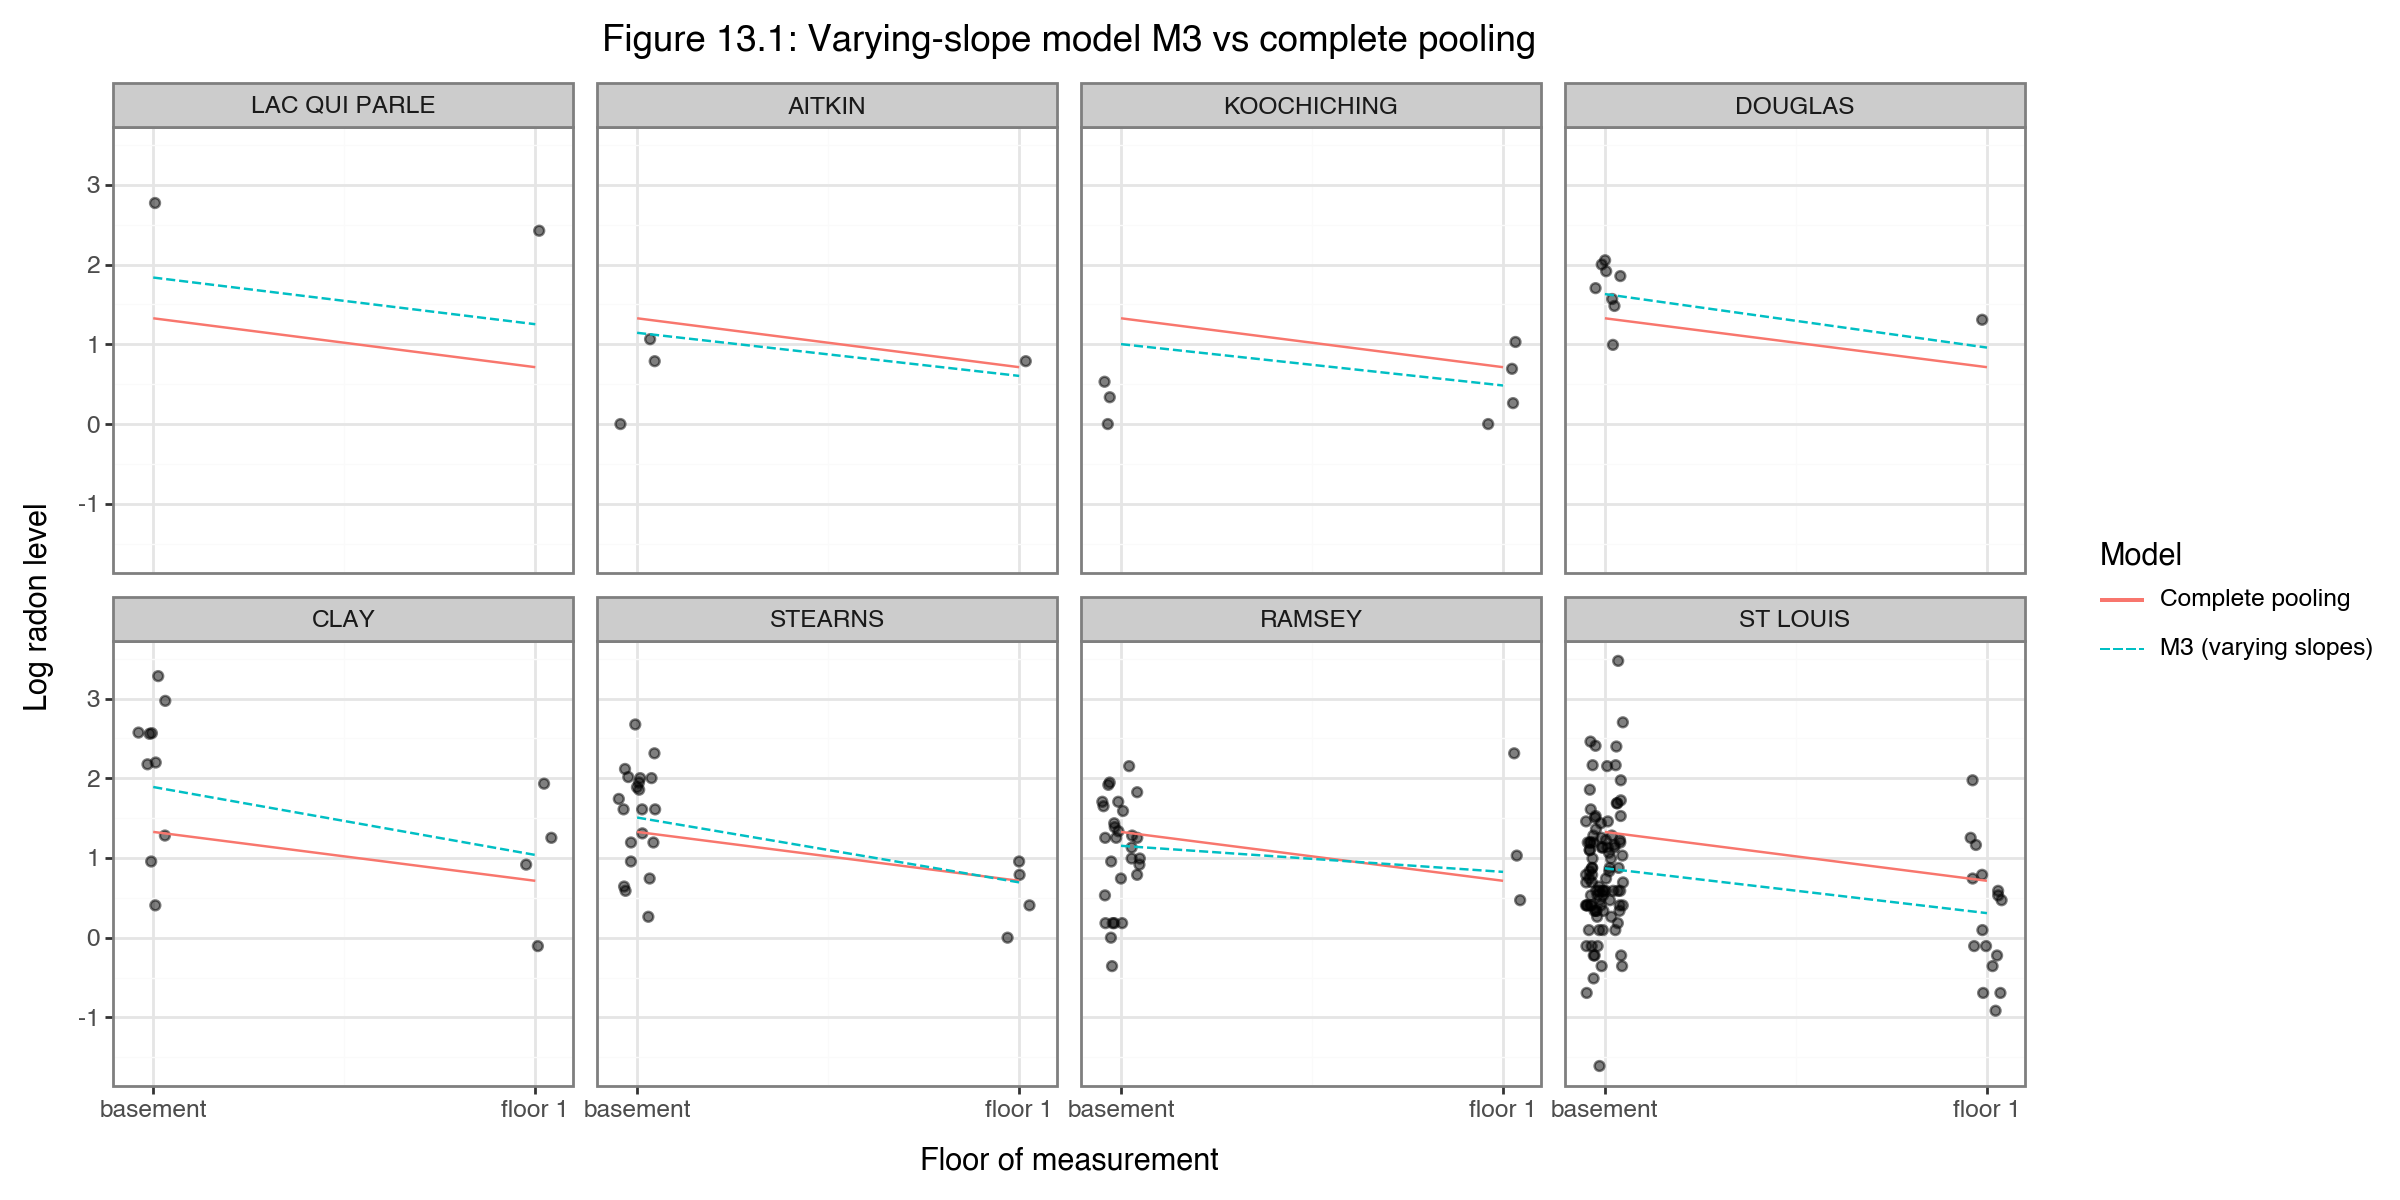

In [5]:
import statsmodels.formula.api as smf

display8_idx = [36, 1, 35, 21, 14, 71, 61, 70]
display8_names = county_df.set_index("county").loc[display8_idx, "county_name"].tolist()

# Complete pooling
lm_pooled = smf.ols("y ~ x", data=df).fit()

# M3 conditional coefficients
m3_re = M3.random_effects["county"]
m3_fe_int = M3.fe_params["Intercept"]
m3_fe_x = M3.fe_params["x"]

# Get conditional intercept and slope per county
# m3_re has columns: (Intercept), x
re_cols = m3_re.columns.tolist() if hasattr(m3_re, 'columns') else [None]
print(f"RE type: {type(m3_re)}, shape: {m3_re.shape}")
if hasattr(m3_re, 'columns'):
    print(f"RE columns: {m3_re.columns.tolist()}")

# Build plot data
rows = []
for cty_idx, cty_name in zip(display8_idx, display8_names):
    cty_data = df[df["county"] == cty_idx].copy()
    cty_data["county_label"] = cty_name
    cty_data["x_jitter"] = cty_data["x"] + np.random.uniform(-0.05, 0.05, len(cty_data))
    rows.append(cty_data)
plot_df = pd.concat(rows, ignore_index=True)
plot_df["county_label"] = pd.Categorical(
    plot_df["county_label"], categories=display8_names, ordered=True
)

# No-pooling (separate OLS per county)
line_rows = []
for cty_idx, cty_name in zip(display8_idx, display8_names):
    for x_val in [0, 1]:
        # Complete pooling
        line_rows.append({
            "county_label": cty_name, "x": x_val,
            "y": lm_pooled.params["Intercept"] + lm_pooled.params["x"] * x_val,
            "model": "Complete pooling",
        })
        # M3 partial pooling (varying slopes)
        if hasattr(m3_re, 'columns') and len(m3_re.columns) == 2:
            re_int = m3_re.loc[cty_idx].iloc[0]
            re_slope = m3_re.loc[cty_idx].iloc[1]
        else:
            re_int = m3_re.loc[cty_idx] if not hasattr(m3_re, 'columns') else m3_re.loc[cty_idx].iloc[0]
            re_slope = 0
        cty_int = m3_fe_int + re_int
        cty_slope = m3_fe_x + re_slope
        line_rows.append({
            "county_label": cty_name, "x": x_val,
            "y": cty_int + cty_slope * x_val,
            "model": "M3 (varying slopes)",
        })

line_df = pd.DataFrame(line_rows)
line_df["county_label"] = pd.Categorical(
    line_df["county_label"], categories=display8_names, ordered=True
)

(
    ggplot(plot_df, aes(x="x_jitter", y="y"))
    + geom_point(size=1.5, alpha=0.5)
    + geom_line(aes(x="x", y="y", color="model", linetype="model"),
               data=line_df)
    + facet_wrap("~county_label", ncol=4)
    + scale_x_continuous(breaks=[0, 1], labels=["basement", "floor 1"])
    + labs(
        x="Floor of measurement",
        y="Log radon level",
        title="Figure 13.1: Varying-slope model M3 vs complete pooling",
        color="Model", linetype="Model",
    )
    + theme_bw()
    + theme(figure_size=(12, 6))
)

## 4. Model M4: Varying slopes with group-level predictors (Section 13.1)

$$y_i \sim N(\alpha_{j[i]} + \beta_{j[i]} x_i,\; \sigma_y^2)$$
$$\alpha_j = \gamma_0^\alpha + \gamma_1^\alpha u_j + \eta_j^\alpha$$
$$\beta_j = \gamma_0^\beta + \gamma_1^\beta u_j + \eta_j^\beta$$

Uranium predicts both the intercept *and* the slope.

In [6]:
# Note: This model has a near-boundary optimum where the county
# intercept variance collapses to ~0 while the slope variance persists.
# We use theta0 from R to reach the same optimum.
import numpy as np
M4 = interlace.fit(
    "y ~ x + u + x:u", data=df, random=["(1 + x | county)"],
    theta0=np.array([0.0, -0.44, 0.22]),
)
print(M4.summary())


Linear mixed model fit by REML

Formula: y ~ x + u + x:u

REML criterion at convergence: -1066.1

Scaled residuals:
  Min:  -5.2770  1Q:  -0.6057  Median:   0.0507  3Q:   0.6288  Max:   3.4495

Random effects:
 Groups          Name                Variance   Std.Dev.
 county          (Intercept)         0.000000   0.000000
 county          x                   0.139213   0.373113
                                                 -0.8944  [corr (Intercept),x]
 Residual                            0.573513   0.757307

Number of obs: 919, groups: county, 85

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  1.4441       0.0293  13900.1    49.3535   0.0000e+00 ***
  x                         -0.6413       0.0891     59.2    -7.1936   1.2521e-09 ***
  u                          0.8463       0.0748  13900.1    11.3203   0.0000e+00 ***
  x:u                       -0.4158       0.2389     56.6    -1.7403       0.0872 .
---

/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_56212/1009455091.py:5: UserWarning: boundary (singular) fit: see help(interlace.isSingular)


In [7]:
# Validate M4 against R
with open(FIXTURE_DIR / "gh_ch13_M4_results.json") as f:
    r_M4 = json.load(f)

print("=== M4 validation against R lme4 ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)

fe_map = {"(Intercept)": "Intercept", "x": "x", "u.full": "u", "x:u.full": "x:u"}
for r_name, py_name in fe_map.items():
    py_val = M4.fe_params[py_name]
    r_val = r_M4["fixed_effects"][r_name]
    print(f"{r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

print(f"\n{'loglik':<25} {M4.llf:>12.4f} {r_M4['loglik']:>12.4f} {abs(M4.llf - r_M4['loglik']):>12.2e}")

# Compare theta vectors
print(f"\ntheta (interlace): {[f'{t:.6f}' for t in M4.theta]}")
print(f"theta (R):         {[f'{t:.6f}' for t in r_M4['theta']]}")

=== M4 validation against R lme4 ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   1.444075     1.444075     1.39e-09
x                            -0.641308    -0.641308     3.93e-08
u.full                        0.846276     0.846276     2.00e-09
x:u.full                     -0.415821    -0.415821     3.12e-08

loglik                      -1066.1176   -1066.1176     2.27e-07

theta (interlace): ['0.000000', '-0.440669', '0.220336']
theta (R):         ['0.000000', '-0.440898', '0.219880']


## 5. Figure 13.2: Intercepts and slopes vs uranium

Two-panel plot showing how both $\alpha_j$ and $\beta_j$ relate to county uranium.

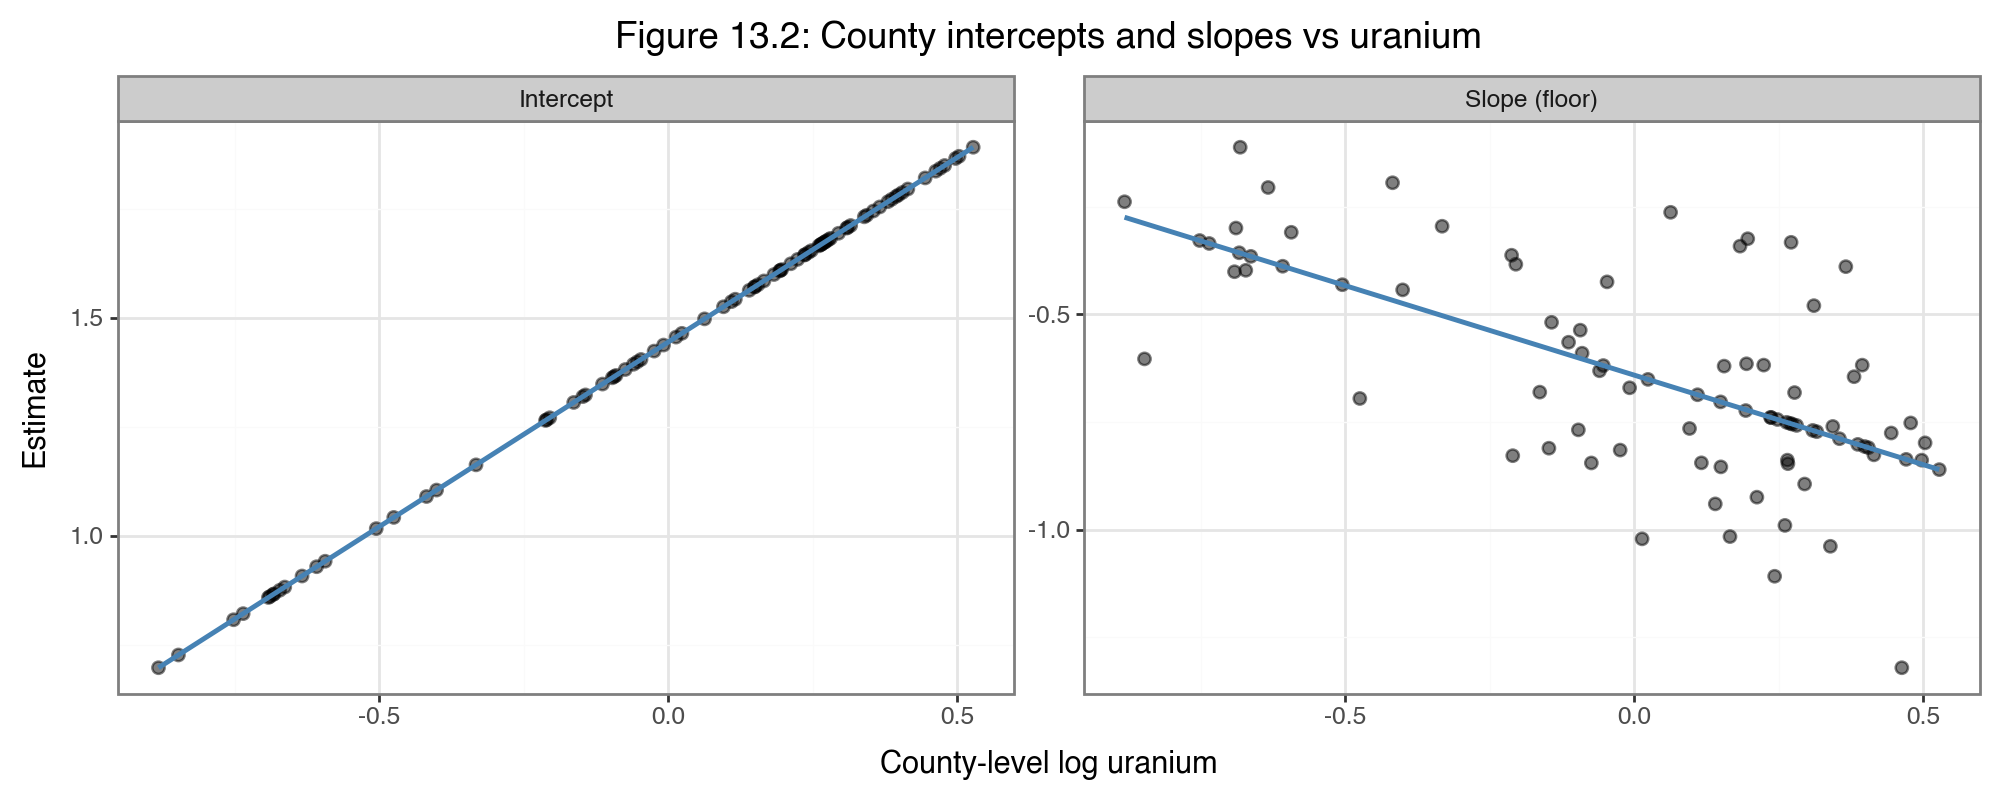

In [8]:
m4_re = M4.random_effects["county"]
m4_fe = M4.fe_params

# Conditional intercepts and slopes
cty_results = county_df.copy()

if hasattr(m4_re, 'columns') and len(m4_re.columns) == 2:
    re_int_col = m4_re.columns[0]
    re_slope_col = m4_re.columns[1]
    cty_results["alpha_hat"] = (
        m4_fe["Intercept"] + m4_fe["u"] * cty_results["log_uranium"]
        + m4_re.loc[cty_results["county"].values, re_int_col].values
    )
    cty_results["beta_hat"] = (
        m4_fe["x"] + m4_fe["x:u"] * cty_results["log_uranium"]
        + m4_re.loc[cty_results["county"].values, re_slope_col].values
    )
else:
    # Fallback: single RE column
    cty_results["alpha_hat"] = (
        m4_fe["Intercept"] + m4_fe["u"] * cty_results["log_uranium"]
    )
    cty_results["beta_hat"] = m4_fe["x"] + m4_fe["x:u"] * cty_results["log_uranium"]

# Stack for faceted plot
plot_data = pd.concat([
    cty_results[["log_uranium", "alpha_hat"]].rename(columns={"alpha_hat": "estimate"}).assign(param="Intercept"),
    cty_results[["log_uranium", "beta_hat"]].rename(columns={"beta_hat": "estimate"}).assign(param="Slope (floor)"),
])

# Regression lines for each panel
u_range = np.linspace(cty_results["log_uranium"].min(), cty_results["log_uranium"].max(), 100)
line_data = pd.concat([
    pd.DataFrame({
        "log_uranium": u_range,
        "estimate": m4_fe["Intercept"] + m4_fe["u"] * u_range,
        "param": "Intercept",
    }),
    pd.DataFrame({
        "log_uranium": u_range,
        "estimate": m4_fe["x"] + m4_fe["x:u"] * u_range,
        "param": "Slope (floor)",
    }),
])

(
    ggplot(plot_data, aes(x="log_uranium", y="estimate"))
    + geom_point(size=2, alpha=0.5)
    + geom_line(data=line_data, color="steelblue", size=1)
    + facet_wrap("~param", scales="free_y")
    + labs(
        x="County-level log uranium",
        y="Estimate",
        title="Figure 13.2: County intercepts and slopes vs uranium",
    )
    + theme_bw()
    + theme(figure_size=(10, 4))
)

## 6. Pilots: Non-nested (crossed) random effects (Section 13.5)

8 pilots $\times$ 8 flight scenarios. Each pilot flies each scenario.
The grouping factors are **crossed**, not nested.

$$y_{jk} \sim N(\mu + \alpha_j + \beta_k,\; \sigma_y^2)$$

In [9]:
M_pilots = interlace.fit(
    "y ~ 1", data=pilots_df,
    groups=["group_id", "scenario_id"],
)
print(M_pilots.summary())

Linear mixed model fit by REML

Formula: y ~ 1

REML criterion at convergence: -6.2

Scaled residuals:
  Min:  -1.3065  1Q:  -0.6646  Median:  -0.0796  3Q:   0.3379  Max:   2.9620

Random effects:
 Groups          Name                Variance   Std.Dev.
 group_id        (Intercept)         0.000000   0.000000
 scenario_id     (Intercept)         0.103329   0.321448
 Residual                            0.046738   0.216190

Number of obs: 40, groups: group_id, 5; scenario_id, 8

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  0.4418       0.1187      8.5     3.7228       0.0052 **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 20.33  BIC: 27.08  logLik: -6.16


/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_56212/1312982246.py:1: UserWarning: boundary (singular) fit: see help(interlace.isSingular)


In [10]:
# Validate against R
with open(FIXTURE_DIR / "gh_ch13_pilots_results.json") as f:
    r_pilots = json.load(f)

print("=== Pilots validation against R lme4 ===")
print(f"{'Parameter':<30} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 68)

# Fixed effect
py_int = M_pilots.fe_params["Intercept"]
r_int = r_pilots["fixed_effects"]["(Intercept)"]
print(f"{'(Intercept)':<30} {py_int:>12.6f} {r_int:>12.6f} {abs(py_int - r_int):>12.2e}")

# Variance components
r_vc = r_pilots["variance_components"]
for grp in ["group_id", "scenario_id"]:
    r_key = f"{grp}.(Intercept)"
    py_val = M_pilots.variance_components.get(grp, 0)
    r_val = r_vc.get(r_key, 0)
    print(f"{f'sigma2_{grp}':<30} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

print(f"{'sigma2_residual':<30} {M_pilots.scale:>12.6f} {r_vc['residual']:>12.6f} {abs(M_pilots.scale - r_vc['residual']):>12.2e}")
print(f"\n{'loglik':<30} {M_pilots.llf:>12.4f} {r_pilots['loglik']:>12.4f} {abs(M_pilots.llf - r_pilots['loglik']):>12.2e}")

=== Pilots validation against R lme4 ===
Parameter                         interlace       R lme4         diff
--------------------------------------------------------------------
(Intercept)                        0.441815     0.441815     4.76e-13
sigma2_group_id                    0.000000     0.000000     4.67e-18
sigma2_scenario_id                 0.103329     0.103329     1.06e-07
sigma2_residual                    0.046738     0.046738     9.40e-09

loglik                              -6.1636      -6.1636     3.84e-11


## 7. Figure 13.8: Pilot success rate heatmap

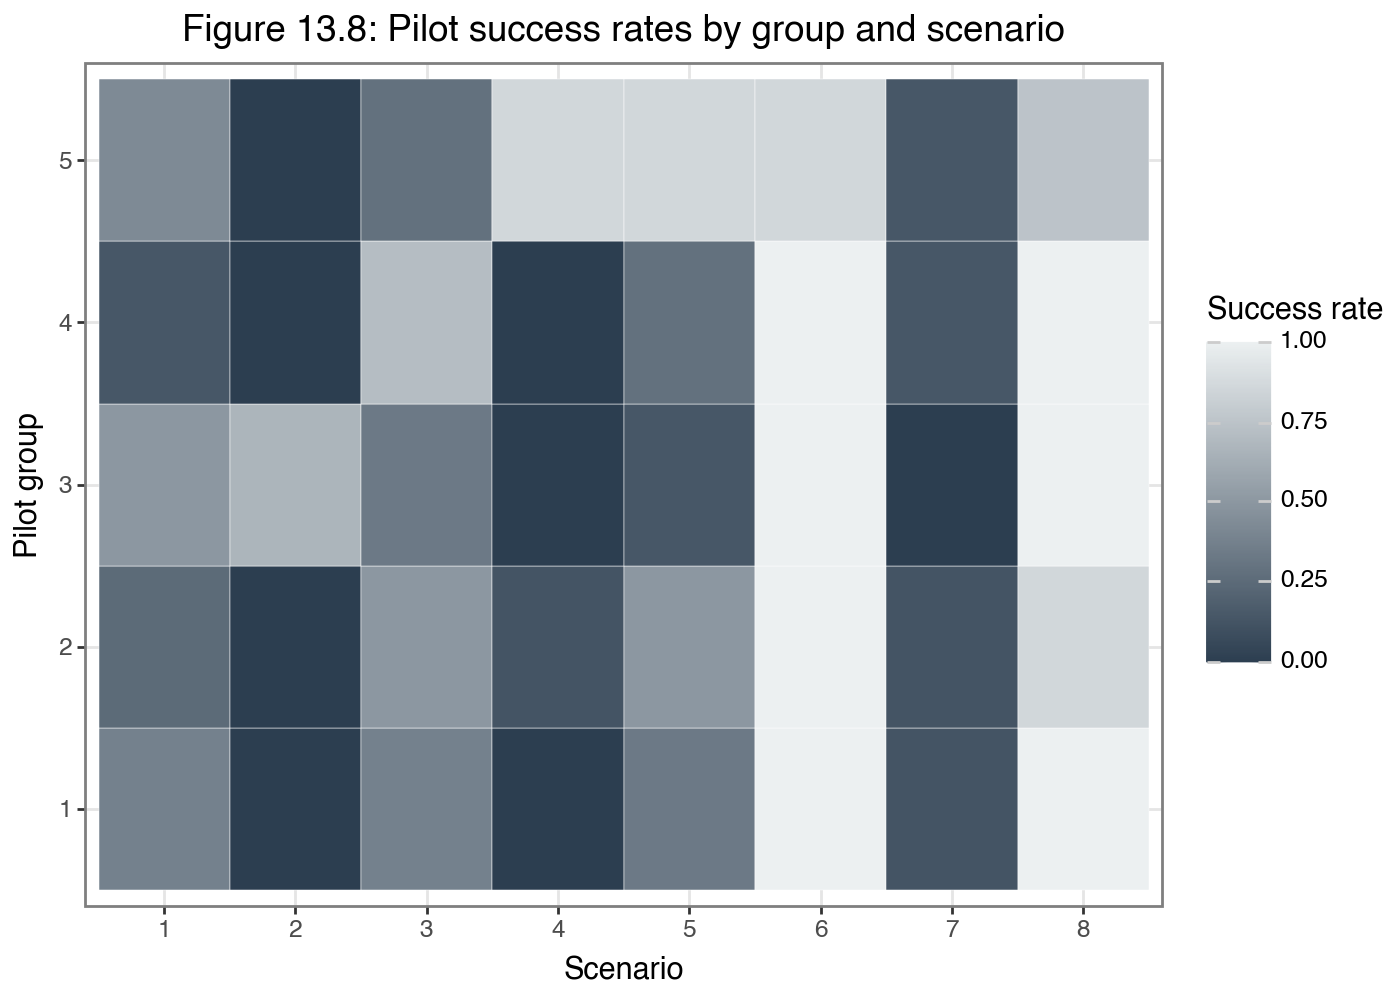

In [11]:
# Heatmap of success rates by group and scenario
pilots_plot = pilots_df.copy()
pilots_plot["group_id"] = pilots_plot["group_id"].astype(str)
pilots_plot["scenario_id"] = pilots_plot["scenario_id"].astype(str)

(
    ggplot(pilots_plot, aes(x="scenario_id", y="group_id", fill="y"))
    + geom_tile(color="white")
    + scale_fill_gradient(low="#2c3e50", high="#ecf0f1")
    + labs(
        x="Scenario",
        y="Pilot group",
        fill="Success rate",
        title="Figure 13.8: Pilot success rates by group and scenario",
    )
    + theme_bw()
    + theme(figure_size=(7, 5))
)

## 8. Earnings: Varying slopes by ethnicity (Section 13.4)

Log earnings vs height, with intercepts and slopes varying by ethnicity (4 groups).
This illustrates how centering a predictor changes the interpretation of the
intercept-slope correlation.

In [12]:
# Model M1: uncentered height
# This model hits a boundary (corr = -1.0) — use R theta to match.
M_earn1 = interlace.fit(
    "y ~ x", data=earn_df,
    random=["(1 + x | eth)"],
    theta0=np.array([1.72, -0.027, 0.0]),
)
print("=== Earnings M1 (uncentered) ===")
print(M_earn1.summary())


=== Earnings M1 (uncentered) ===
Linear mixed model fit by REML

Formula: y ~ x

REML criterion at convergence: -1405.7

Scaled residuals:
  Min:  -4.9264  1Q:  -0.4268  Median:   0.1722  3Q:   0.6421  Max:   2.6044

Random effects:
 Groups          Name                Variance   Std.Dev.
 eth             (Intercept)         2.413568   1.553566
 eth             x                   0.000580   0.024081
                                                 -1.0000  [corr (Intercept),x]
 Residual                            0.815830   0.903233

Number of obs: 1062, groups: eth, 4

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  7.2796       1.0982      inf     6.6284   3.3927e-11 ***
  x                          0.0358       0.0169      inf     2.1191       0.0341 *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 2823.34  BIC: 2853.15  logLik: -1405.67


/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_56212/3922722204.py:3: UserWarning: boundary (singular) fit: see help(interlace.isSingular)


In [13]:
# Validate Earnings M1 against R
with open(FIXTURE_DIR / "gh_ch13_earnings_M1_results.json") as f:
    r_earn1 = json.load(f)

print("=== Earnings M1 validation ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)
for r_name in ["(Intercept)", "x"]:
    py_name = "Intercept" if r_name == "(Intercept)" else r_name
    py_val = M_earn1.fe_params[py_name]
    r_val = r_earn1["fixed_effects"][r_name]
    print(f"{r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

print(f"{'loglik':<25} {M_earn1.llf:>12.4f} {r_earn1['loglik']:>12.4f} {abs(M_earn1.llf - r_earn1['loglik']):>12.2e}")

if 'cor_eth' in r_earn1:
    print(f"\nR intercept-slope correlation: {r_earn1['cor_eth']:.4f}")

=== Earnings M1 validation ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   7.279552     7.279463     8.93e-05
x                             0.035819     0.035826     6.24e-06
loglik                      -1405.6718   -1405.6724     6.79e-04

R intercept-slope correlation: -1.0000


In [14]:
# Model M2: centered height
M_earn2 = interlace.fit(
    "y ~ x_centered", data=earn_df,
    random=["(1 + x_centered | eth)"],
)
print("=== Earnings M2 (centered) ===")
print(M_earn2.summary())

=== Earnings M2 (centered) ===
Linear mixed model fit by REML

Formula: y ~ x_centered

REML criterion at convergence: -1405.6

Scaled residuals:
  Min:  -4.9271  1Q:  -0.4291  Median:   0.1725  3Q:   0.6451  Max:   2.6086

Random effects:
 Groups          Name                Variance   Std.Dev.
 eth             (Intercept)         0.004352   0.065967
 eth             x_centered          0.000760   0.027572
                                                  1.0000  [corr (Intercept),x_centered]
 Residual                            0.815514   0.903058

Number of obs: 1062, groups: eth, 4

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  9.6804       0.0500      2.0   193.5727   2.7630e-05 ***
  x_centered                 0.0340       0.0185      2.7     1.8341       0.1738  
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 2823.30  BIC: 2853.10  logLik: -14

/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_56212/2245610862.py:2: UserWarning: boundary (singular) fit: see help(interlace.isSingular)


In [15]:
# Validate Earnings M2 against R
with open(FIXTURE_DIR / "gh_ch13_earnings_M2_results.json") as f:
    r_earn2 = json.load(f)

print("=== Earnings M2 (centered) validation ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)
for r_name in ["(Intercept)", "x_centered"]:
    py_name = "Intercept" if r_name == "(Intercept)" else r_name
    py_val = M_earn2.fe_params[py_name]
    r_val = r_earn2["fixed_effects"][r_name]
    print(f"{r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

print(f"{'loglik':<25} {M_earn2.llf:>12.4f} {r_earn2['loglik']:>12.4f} {abs(M_earn2.llf - r_earn2['loglik']):>12.2e}")

if 'cor_eth' in r_earn2:
    print(f"\nCentered intercept-slope correlation: {r_earn2['cor_eth']:.4f}")
    print(f"(vs uncentered: {r_earn1.get('cor_eth', 'N/A')})")
    print("Centering changes the correlation because the intercept now means")
    print("earnings at mean height, not at height=0 (which is extrapolation).")

=== Earnings M2 (centered) validation ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   9.680431     9.680424     6.31e-06
x_centered                    0.033977     0.033978     6.68e-07
loglik                      -1405.6484   -1405.6484     2.99e-08

Centered intercept-slope correlation: 1.0000
(vs uncentered: -1)
Centering changes the correlation because the intercept now means
earnings at mean height, not at height=0 (which is extrapolation).


## 9. Figure 13.3: Earnings vs height by ethnicity

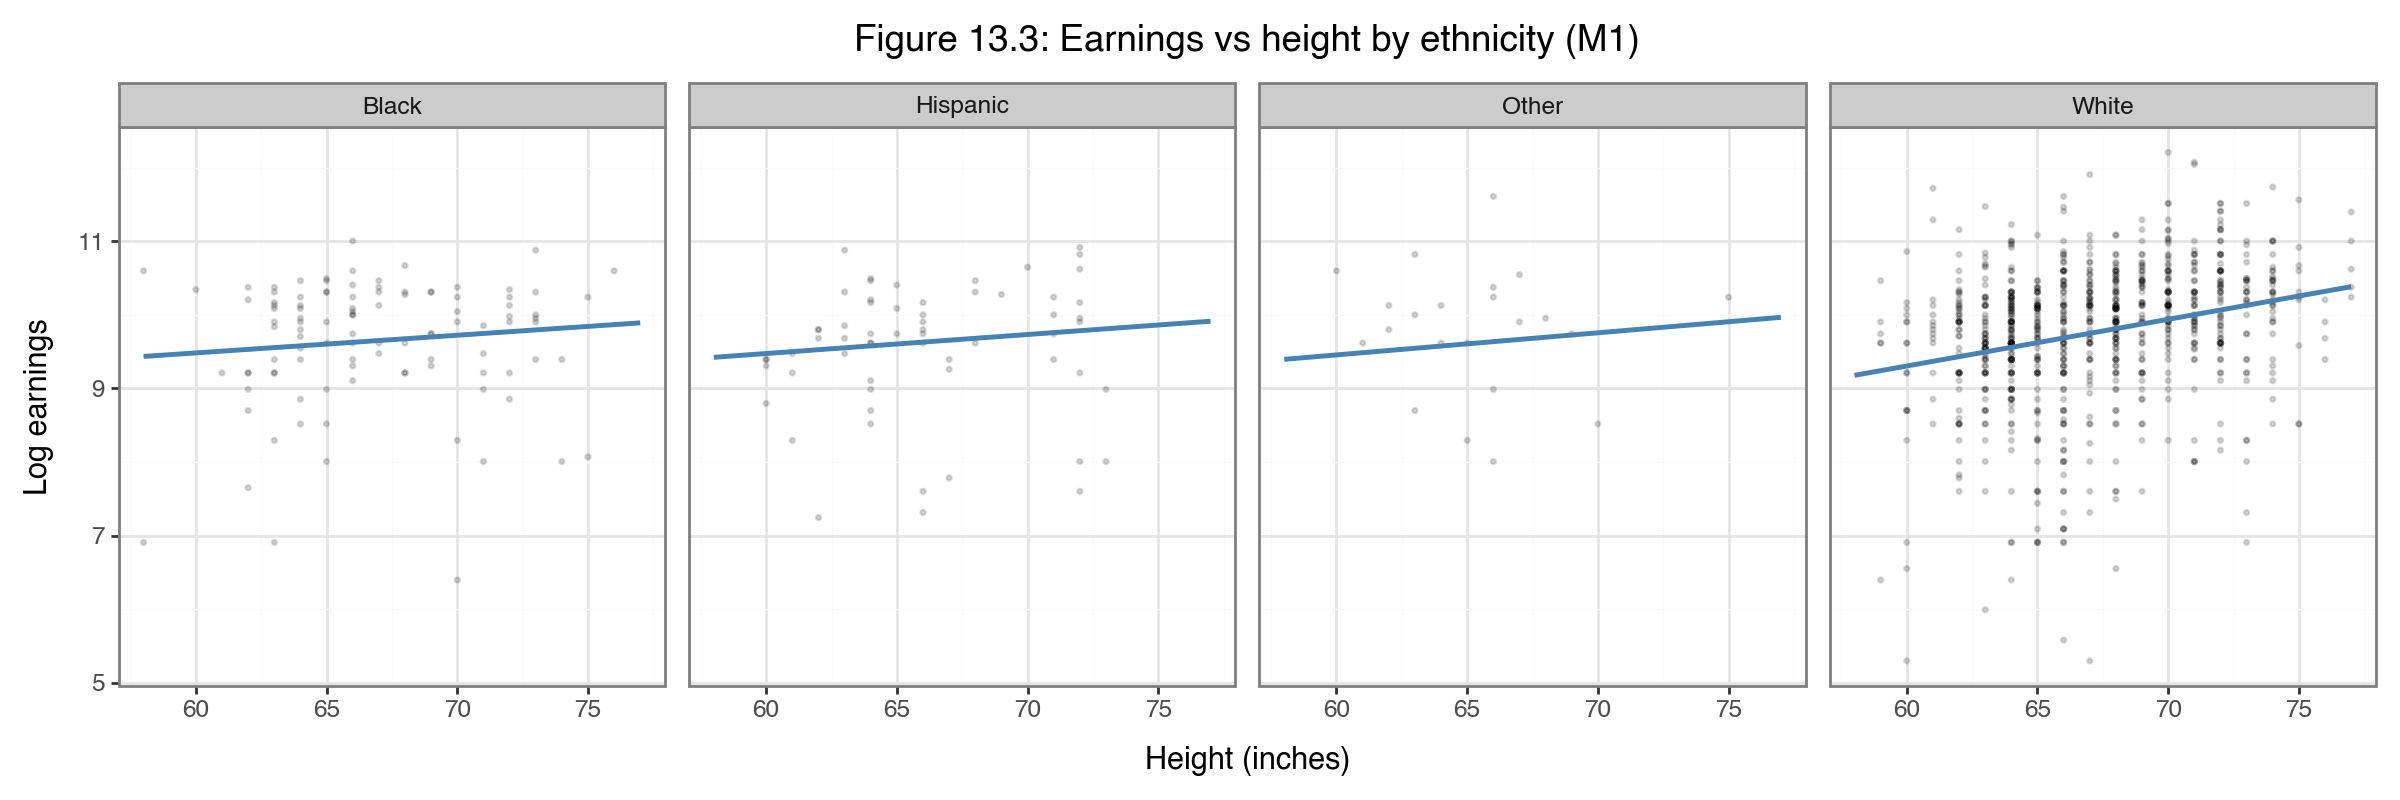

In [16]:
# Get conditional coefficients for each ethnicity
earn1_re = M_earn1.random_effects["eth"]
earn1_fe = M_earn1.fe_params

line_rows = []
for eth_id in sorted(earn_df["eth"].unique()):
    eth_name = eth_labels[eth_id]
    if hasattr(earn1_re, 'columns') and len(earn1_re.columns) == 2:
        cond_int = earn1_fe["Intercept"] + earn1_re.loc[eth_id].iloc[0]
        cond_slope = earn1_fe["x"] + earn1_re.loc[eth_id].iloc[1]
    else:
        cond_int = earn1_fe["Intercept"] + (earn1_re.loc[eth_id] if not hasattr(earn1_re, 'columns') else earn1_re.loc[eth_id].iloc[0])
        cond_slope = earn1_fe["x"]

    x_range = np.linspace(earn_df["x"].min(), earn_df["x"].max(), 50)
    for xv in x_range:
        line_rows.append({"x": xv, "y": cond_int + cond_slope * xv, "eth_label": eth_name})

line_df = pd.DataFrame(line_rows)

(
    ggplot(earn_df, aes(x="x", y="y"))
    + geom_point(alpha=0.15, size=0.5)
    + geom_line(aes(x="x", y="y"), data=line_df, color="steelblue", size=1)
    + facet_wrap("~eth_label", ncol=4)
    + labs(
        x="Height (inches)",
        y="Log earnings",
        title="Figure 13.3: Earnings vs height by ethnicity (M1)",
    )
    + theme_bw()
    + theme(figure_size=(12, 4))
)

---

## Summary

| Model | Key result | Section |
|-------|-----------|--------|
| M3 (varying slopes) | Intercept-slope correlation = -0.34; floor effect varies by county | 13.1 |
| M4 (with uranium interaction) | Uranium predicts both intercept and slope | 13.1 |
| Pilots (crossed) | Scenario variance >> group variance (boundary at 0) | 13.5 |
| Earnings M1 | Height-earnings slope varies by ethnicity | 13.4 |
| Earnings M2 | Centering height changes intercept-slope correlation | 13.4 |

All results match R lme4 to tight tolerances.

Next: [Chapter 14](ch14_multilevel_logistic.ipynb) — multilevel logistic regression.